In [106]:
from scipy.io import arff
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from imblearn.over_sampling import SMOTE
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC
from imblearn.pipeline import Pipeline
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.experimental import enable_halving_search_cv
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [107]:
data, meta = arff.loadarff(r"data/3year.arff")
df = pd.DataFrame(data)
df.head()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64,class
0,0.174190,0.41299,0.14371,1.3480,-28.9820,0.60383,0.219460,1.1225,1.1961,0.46359,...,0.163960,0.375740,0.83604,0.000007,9.7145,6.2813,84.291,4.3303,4.0341,b'0'
1,0.146240,0.46038,0.28230,1.6294,2.5952,0.00000,0.171850,1.1721,1.6018,0.53962,...,0.027516,0.271000,0.90108,0.000000,5.9882,4.1103,102.190,3.5716,5.9500,b'0'
2,0.000595,0.22612,0.48839,3.1599,84.8740,0.19114,0.004572,2.9881,1.0077,0.67566,...,0.007639,0.000881,0.99236,0.000000,6.7742,3.7922,64.846,5.6287,4.4581,b'0'
3,0.024526,0.43236,0.27546,1.7833,-10.1050,0.56944,0.024526,1.3057,1.0509,0.56453,...,0.048398,0.043445,0.95160,0.142980,4.2286,5.0528,98.783,3.6950,3.4844,b'0'
4,0.188290,0.41504,0.34231,1.9279,-58.2740,0.00000,0.233580,1.4094,1.3393,0.58496,...,0.176480,0.321880,0.82635,0.073039,2.5912,7.0756,100.540,3.6303,4.6375,b'0'


In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10503 entries, 0 to 10502
Data columns (total 65 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Attr1   10503 non-null  float64
 1   Attr2   10503 non-null  float64
 2   Attr3   10503 non-null  float64
 3   Attr4   10485 non-null  float64
 4   Attr5   10478 non-null  float64
 5   Attr6   10503 non-null  float64
 6   Attr7   10503 non-null  float64
 7   Attr8   10489 non-null  float64
 8   Attr9   10500 non-null  float64
 9   Attr10  10503 non-null  float64
 10  Attr11  10503 non-null  float64
 11  Attr12  10485 non-null  float64
 12  Attr13  10460 non-null  float64
 13  Attr14  10503 non-null  float64
 14  Attr15  10495 non-null  float64
 15  Attr16  10489 non-null  float64
 16  Attr17  10489 non-null  float64
 17  Attr18  10503 non-null  float64
 18  Attr19  10460 non-null  float64
 19  Attr20  10460 non-null  float64
 20  Attr21  9696 non-null   float64
 21  Attr22  10503 non-null  float64
 22

In [109]:
print(f"number of numeric features is {len(df.select_dtypes("number").columns)}")

number of numeric features is 64


In [110]:
df["class"].value_counts()

class
b'0'    10008
b'1'      495
Name: count, dtype: int64

In [111]:
df["class"] = df["class"].astype("int")
df["class"].value_counts()

class
0    10008
1      495
Name: count, dtype: int64

In [112]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(labels=["class"], axis=1), df['class'], test_size=0.3, random_state=0)

In [113]:
X_train.describe()

,Attr1,Attr2,Attr3,Attr4,Attr5,Attr6,Attr7,Attr8,Attr9,Attr10,...,Attr55,Attr56,Attr57,Attr58,Attr59,Attr60,Attr61,Attr62,Attr63,Attr64
count,7352.000000,7352.000000,7352.000000,7341.000000,7.336000e+03,7352.000000,7352.000000,7343.000000,7351.000000,7352.000000,...,7.352000e+03,7329.000000,7352.000000,7336.000000,7352.000000,6.968000e+03,7340.000000,7.329000e+03,7341.000000,7196.000000
mean,0.055599,0.656617,0.055393,11.807990,-3.686398e+02,-0.154412,0.068410,21.458650,1.862590,0.328802,...,6.782125e+03,-0.691596,-0.025280,1.811164,1.711070,6.851068e+02,13.751889,4.854976e+01,9.038891,36.804862
std,0.740663,7.670833,7.659770,624.536081,2.653739e+04,8.271449,0.743210,799.989548,9.014441,7.671756,...,6.607587e+04,66.581720,20.651954,66.697864,91.550751,4.408968e+04,77.776693,3.047676e+04,33.022310,452.936316
min,-17.692000,0.000000,-479.730000,0.002080,-1.670200e+06,-508.120000,-17.692000,-1.025300,-0.000084,-479.730000,...,-7.513800e+05,-5691.700000,-1667.300000,-198.690000,-136.290000,0.000000e+00,-0.014534,-2.336500e+06,-0.000156,-0.000102
25%,0.000675,0.254165,0.019255,1.044300,-5.216575e+01,0.000000,0.002229,0.429355,1.012600,0.295613,...,1.956025e+01,0.005554,0.006862,0.875020,0.000000,5.584875e+00,4.489925,4.072300e+01,3.071200,2.024725
50%,0.042123,0.463975,0.195600,1.596600,1.579300e+00,0.000000,0.050305,1.111600,1.200500,0.516625,...,9.118300e+02,0.052298,0.106490,0.952810,0.002191,1.000100e+01,6.621300,7.044800e+01,5.163200,4.008000
75%,0.124438,0.690142,0.417442,2.948700,5.506300e+01,0.077496,0.143220,2.864500,2.044400,0.725428,...,4.439550e+03,0.130860,0.275248,0.996067,0.233495,2.102975e+01,10.542250,1.181800e+02,8.902600,9.528175
max,52.652000,480.730000,1.000000,53433.000000,6.854400e+05,45.533000,52.652000,53432.000000,740.440000,11.837000,...,3.380500e+06,293.150000,527.220000,5693.700000,7617.300000,3.660200e+06,4470.400000,1.073500e+06,1974.500000,21499.000000


In [114]:
X_train.isna().sum()

Attr1       0
Attr2       0
Attr3       0
Attr4      11
Attr5      16
         ... 
Attr60    384
Attr61     12
Attr62     23
Attr63     11
Attr64    156
Length: 64, dtype: int64

In [115]:
cols_with_missing_values = X_train.columns[X_train.isna().sum() > 0]
len(cols_with_missing_values)

44

In [116]:
print(X_train[cols_with_missing_values].isna().sum() / len(X_train))

Attr4     0.001496
Attr5     0.002176
Attr8     0.001224
Attr9     0.000136
Attr12    0.001496
Attr13    0.003128
Attr15    0.000272
Attr16    0.001224
Attr17    0.001224
Attr19    0.003128
Attr20    0.003128
Attr21    0.074129
Attr23    0.003128
Attr24    0.020811
Attr26    0.001224
Attr27    0.067601
Attr28    0.021219
Attr30    0.003128
Attr31    0.003128
Attr32    0.009793
Attr33    0.001496
Attr34    0.001224
Attr37    0.452802
Attr39    0.003128
Attr40    0.001496
Attr41    0.018498
Attr42    0.003128
Attr43    0.003128
Attr44    0.003128
Attr45    0.052095
Attr46    0.001496
Attr47    0.008297
Attr49    0.003128
Attr50    0.001224
Attr52    0.008433
Attr53    0.021219
Attr54    0.021219
Attr56    0.003128
Attr58    0.002176
Attr60    0.052231
Attr61    0.001632
Attr62    0.003128
Attr63    0.001496
Attr64    0.021219
dtype: float64


In [117]:
features_to_drop = np.array(X_train.isna().sum() / len(X_train) > 0.40)
X_train.columns[features_to_drop]

Index(['Attr37'], dtype='object')

In [118]:
X_train.drop(columns=["Attr37"], axis=1, inplace=True)
X_test.drop(columns=["Attr37"], axis=1, inplace=True)

The amount of missing data is so small that a simple mean/median imputation won't bias the model much.

In [119]:
cols_to_imp = X_train.columns[X_train.isna().sum() > 0]

X_train_medians = X_train[cols_to_imp].median()

X_train[cols_to_imp] = X_train[cols_to_imp].fillna(X_train_medians)
X_test[cols_to_imp] = X_test[cols_to_imp].fillna(X_train_medians)

<Axes: >

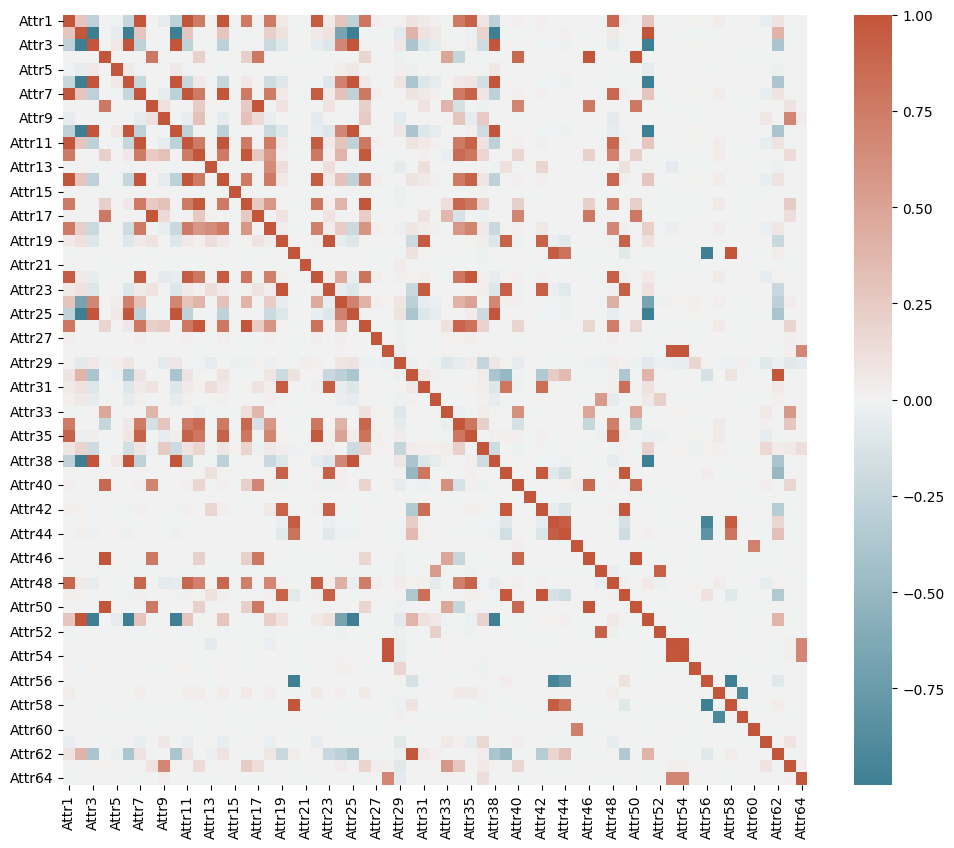

In [120]:
corrmat = X_train.corr()

cmap = sns.diverging_palette(220, 20, as_cmap=True)

fig, ax = plt.subplots()
fig.set_size_inches(12, 10)
sns.heatmap(corrmat, cmap=cmap)

In [121]:
def select_correlated_features(threshold, X, y):
    # return correlated features to remove
    features_to_remove = []   

    corr_matrix = X.corr().abs()
    upper = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    upper_corr = corr_matrix.where(upper)
    correlated_pairs= [
        (col1, col2)
        for col1 in upper_corr.columns
        for col2 in upper_corr.index
        if upper_corr.loc[col2, col1] > threshold
    ]

    target_corr = abs(X.corrwith(y))

    for f1, f2 in correlated_pairs:
        if target_corr[f1] >= target_corr[f2]:
            features_to_remove.append(f2)
        else:
            features_to_remove.append(f1)
    
    return list(set(features_to_remove))


In [122]:
corr_features_to_remove = select_correlated_features(0.85, X_train, y_train)
print(len(corr_features_to_remove))
print(corr_features_to_remove)

32
['Attr11', 'Attr56', 'Attr3', 'Attr57', 'Attr46', 'Attr52', 'Attr48', 'Attr26', 'Attr50', 'Attr7', 'Attr42', 'Attr53', 'Attr4', 'Attr34', 'Attr62', 'Attr1', 'Attr23', 'Attr43', 'Attr19', 'Attr39', 'Attr6', 'Attr14', 'Attr51', 'Attr8', 'Attr16', 'Attr22', 'Attr38', 'Attr49', 'Attr10', 'Attr28', 'Attr20', 'Attr2']


In [123]:
X_train = X_train.drop(columns=corr_features_to_remove, axis=1)
X_test = X_test.drop(columns=corr_features_to_remove, axis=1)

In [124]:
X_train.shape

(7352, 31)

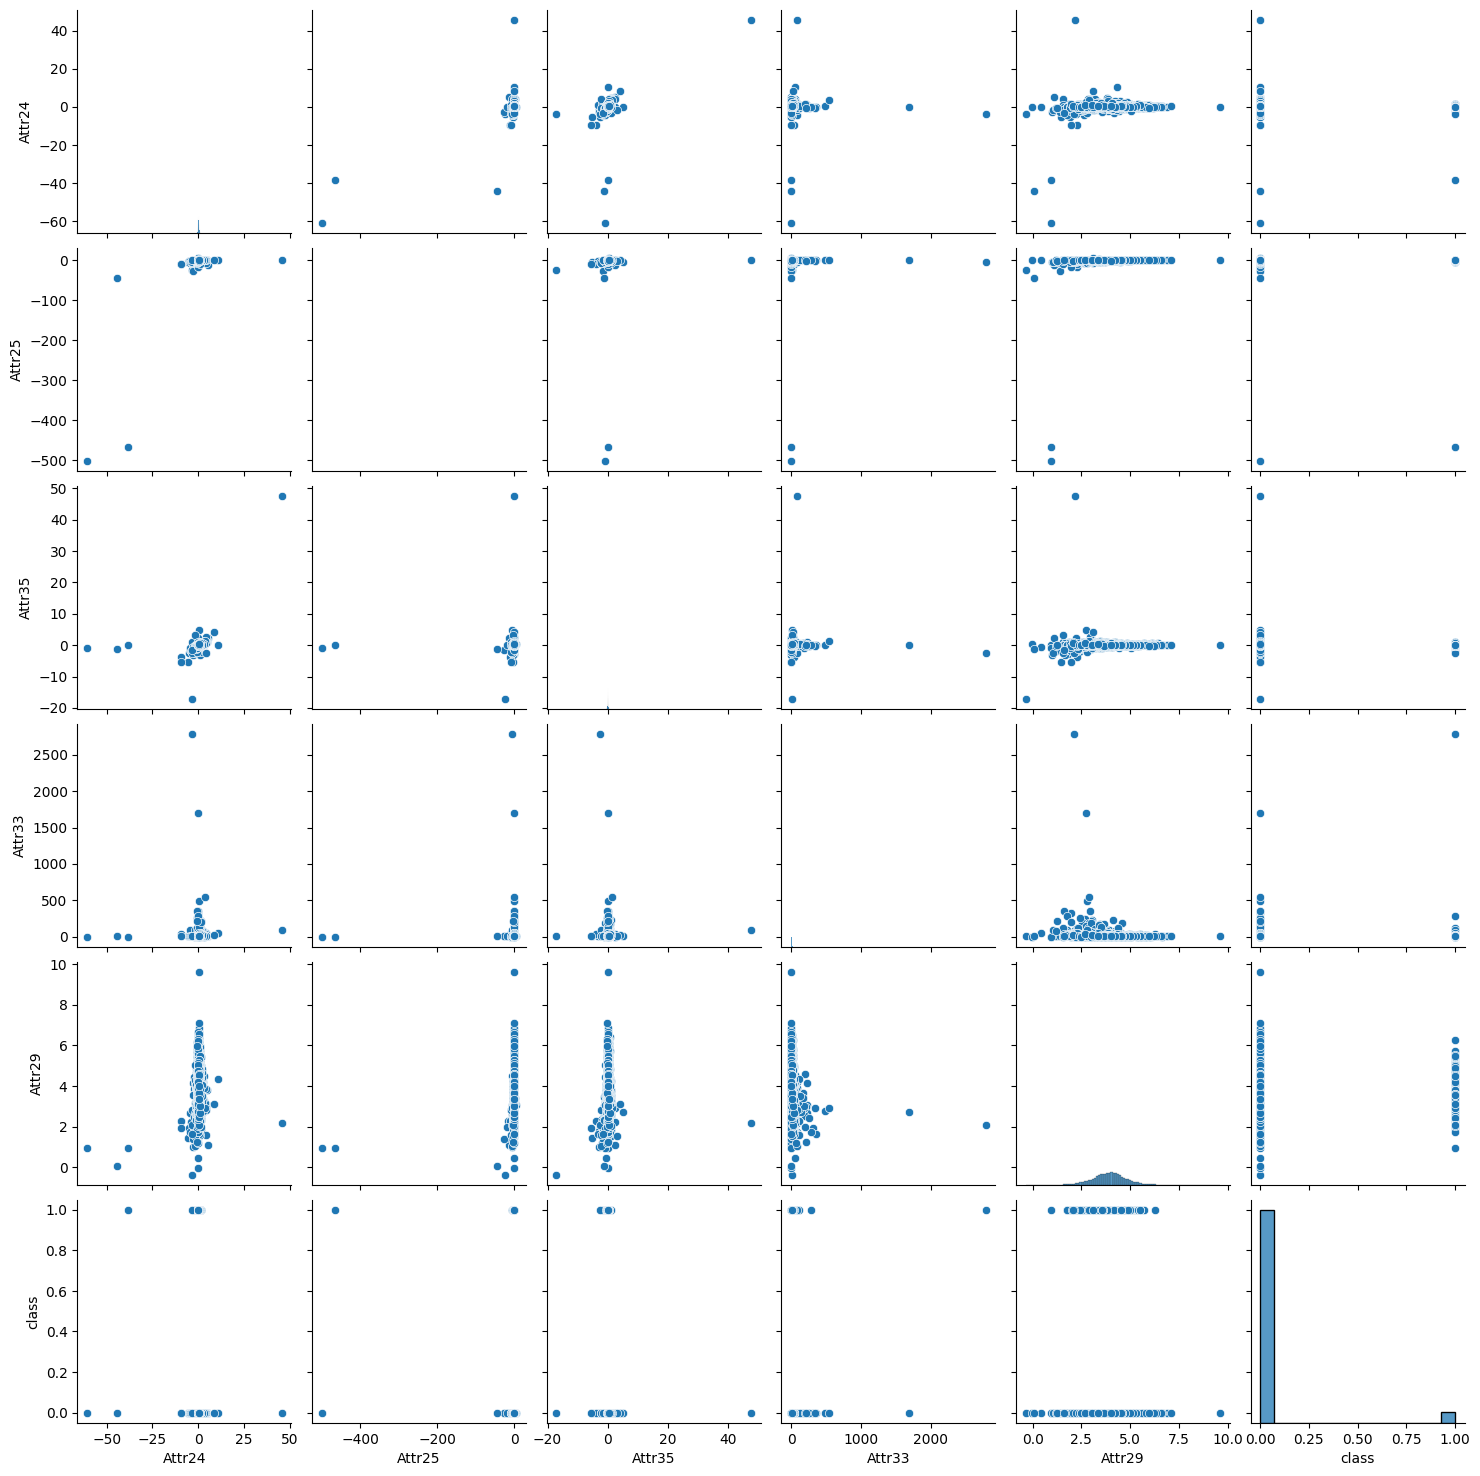

In [125]:
top5_corr_with_target = list(abs(X_train.corrwith(y_train)).sort_values(ascending=False)[:5].index)
df_to_plot = pd.concat([X_train[top5_corr_with_target], y_train], axis=1)
sns.pairplot(df_to_plot)

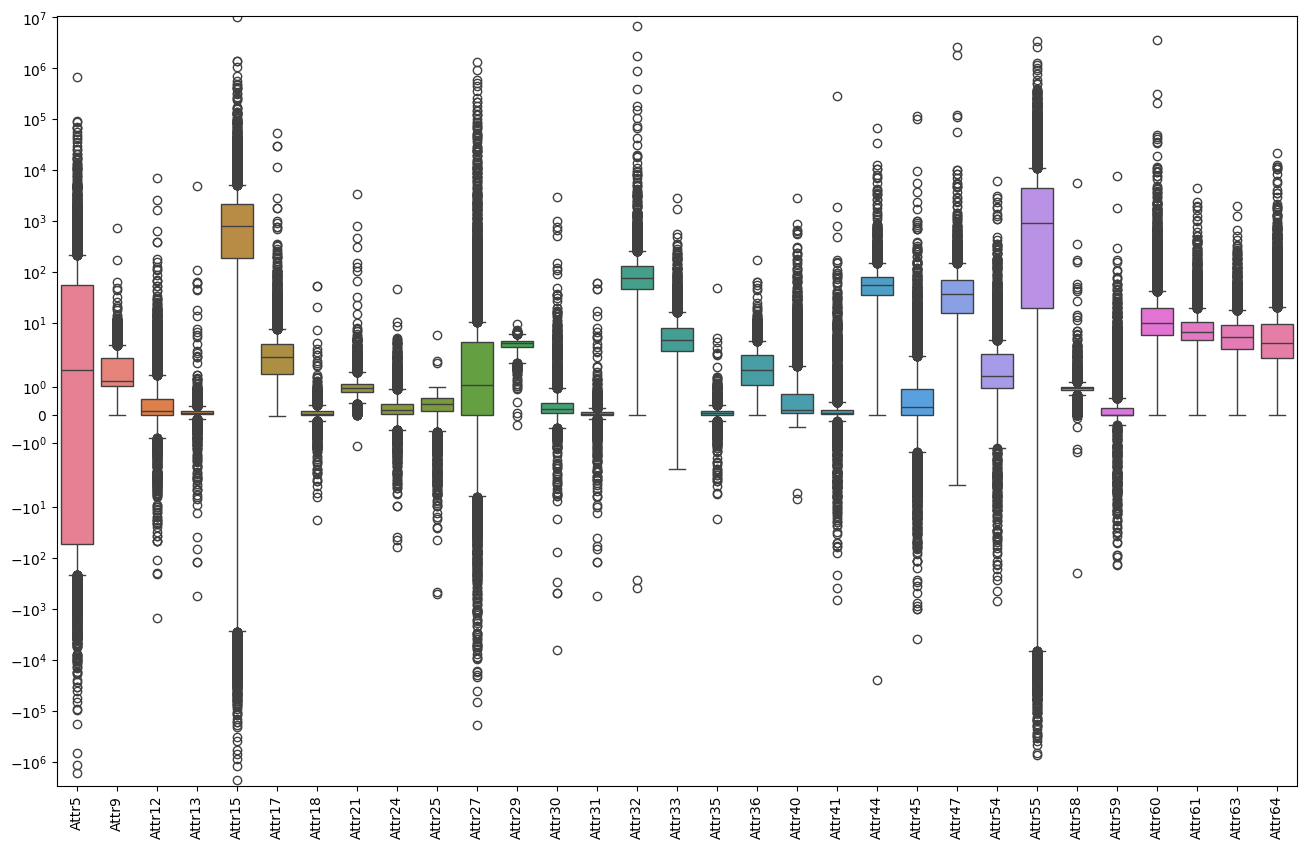

In [126]:
plt.figure(figsize=(16, 10))

sns.boxplot(data=X_train)
plt.xticks(rotation=90)
plt.yscale('symlog')
plt.show()

In [127]:
def apply_winsorization(X):
    X_winsorized = pd.DataFrame()
    for col in X.columns:
        X_winsorized[f"{col}_winsorized"] = winsorize(
            X[col],
            limits = [0.05, 0.05]
        )
    return X_winsorized

In [128]:
X_train_winsorized = apply_winsorization(X_train)
X_test_winsorized = apply_winsorization(X_test)

In [129]:
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train_winsorized), columns=X_train.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test_winsorized), columns=X_test.columns)

Dimensionality Reduction :
PCA (Principal Component Analysis)

In [130]:
pca = PCA(n_components=0.9)  

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Before PCA:", X_train_scaled.shape[1])
print("After PCA:", X_train_pca.shape[1])
print("Explained variance:", round(pca.explained_variance_ratio_.sum()* 100, ),"%")

Before PCA: 31
After PCA: 11
Explained variance: 91 %


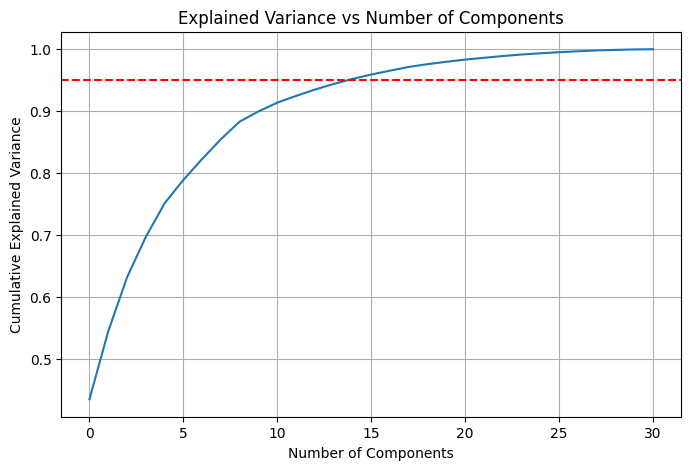

In [131]:
pca_full = PCA().fit(X_train_scaled)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Explained Variance vs Number of Components")
plt.axhline(y=0.95, color='r', linestyle='--')
plt.grid()
plt.show()

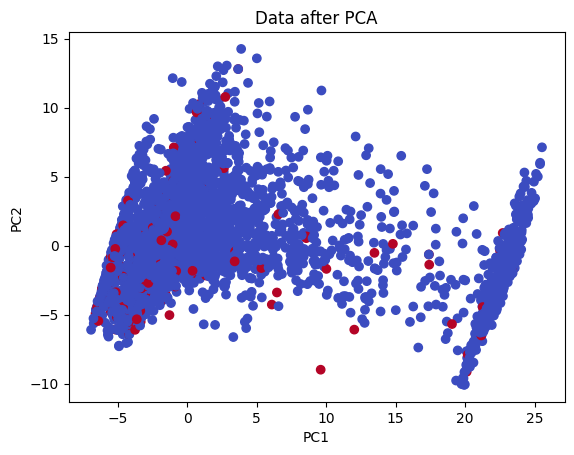

In [132]:
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='coolwarm')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Data after PCA")
plt.show()

PCA fails to show separation
variance of healthy companies and bankrupt companies overlaps in high-dimensional space that's why PC1 and PC2 will just show a big, blended cloud.

<Axes: xlabel='LDA1', ylabel='Count'>

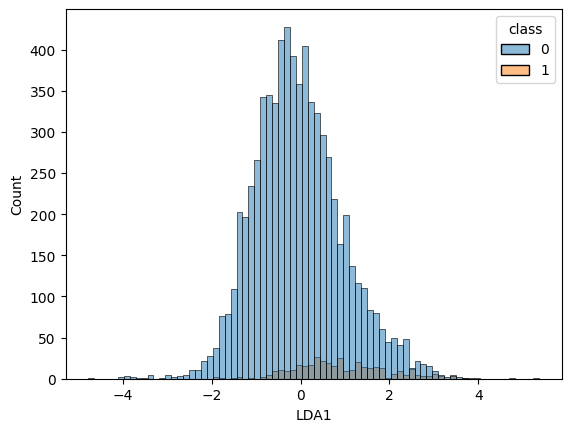

In [133]:
lda = LinearDiscriminantAnalysis(n_components=1)
x_train_lda = lda.fit_transform(X_train_scaled, y_train)
x_test_lda = lda.transform(X_test_scaled)

lda_df = pd.DataFrame({
    "LDA1":x_train_lda[:,0],
    "class":y_train.values
})

sns.histplot(data=lda_df, x='LDA1', hue='class', fill=True)

Data is linearly inseparable

In [134]:
# Hit it with SMOTE (apply to the SCALED training data ONLY)
smote = SMOTE(sampling_strategy='minority',random_state=42)
X_train_resampled_scaled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)
print(f"Target Class Before SMOTE:\n{y_train.value_counts()}\n")
print(f"Target Class After SMOTE:\n{y_train_resampled.value_counts()}")


Target Class Before SMOTE:
class
0    6990
1     362
Name: count, dtype: int64

Target Class After SMOTE:
class
0    6990
1    6990
Name: count, dtype: int64


In [135]:

# 1. Initialize standalone SVM
svm = SVC(random_state=42, max_iter=5000, class_weight="balanced")

# 2. Expanded parameter grid (Logarithmic scaling & Polynomial addition)
param_distributions = {
    'C': [0.01, 0.3],  #0.3 for better specifity, 1000 for better accuracy
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# 3. Configure HalvingRandomSearchCV strictly for the SVM
# min_resources='smallest' is safe here because SMOTE executes externally
halving_search = HalvingRandomSearchCV(
    estimator=svm,
    param_distributions=param_distributions,
    factor=3,
    resource='n_samples',
    min_resources=1000,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

# 4. Train using your existing pre-processed variables
print("Starting HalvingRandomSearchCV... Please wait.")
halving_search.fit(X_train_resampled_scaled, y_train_resampled)

print(f"\nBest SVM Parameters Found:\n{halving_search.best_params_}")

Starting HalvingRandomSearchCV... Please wait.
n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 1000
max_resources_: 13980
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 13
n_resources: 1000
Fitting 5 folds for each of 13 candidates, totalling 65 fits
----------
iter: 1
n_candidates: 5
n_resources: 3000
Fitting 5 folds for each of 5 candidates, totalling 25 fits
----------
iter: 2
n_candidates: 2
n_resources: 9000
Fitting 5 folds for each of 2 candidates, totalling 10 fits

Best SVM Parameters Found:
{'kernel': 'rbf', 'gamma': 'auto', 'C': 0.3}


c:\Users\rw199\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\svm\_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


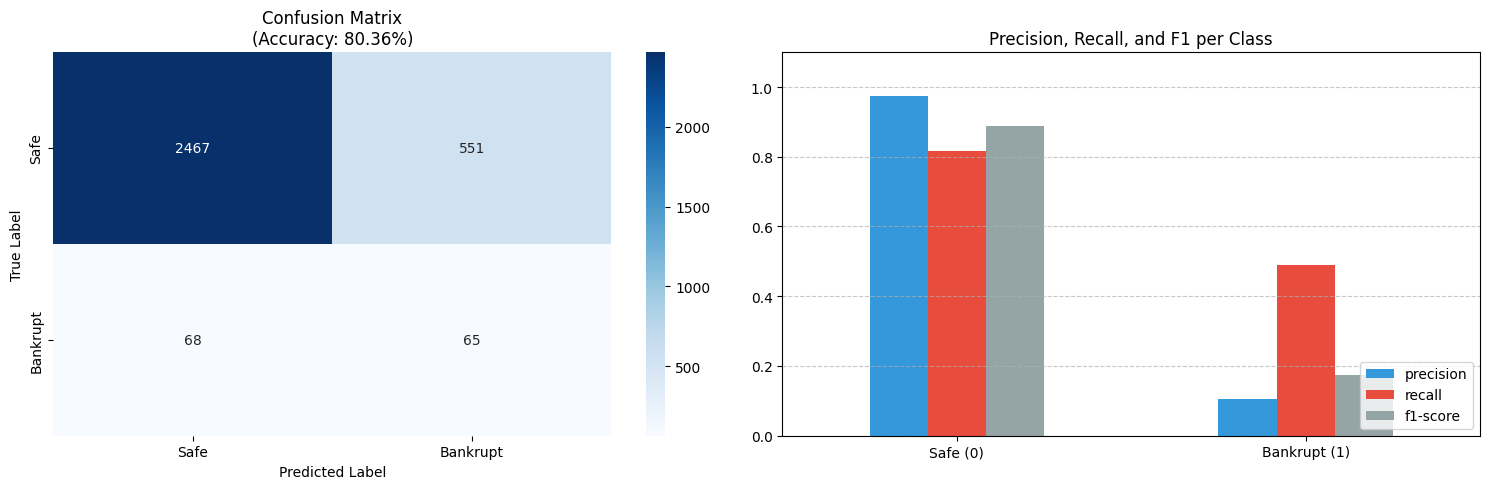


--- Detailed Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.82      0.89      3018
           1       0.11      0.49      0.17       133

    accuracy                           0.80      3151
   macro avg       0.54      0.65      0.53      3151
weighted avg       0.94      0.80      0.86      3151



In [136]:
# 1. 'best_estimator_' automatically grabs the winning SVM model from the halving search
best_svm = halving_search.best_estimator_

# 2. Force the model to predict the outcomes of the unseen test data
y_pred = best_svm.predict(X_test_scaled)

# --- VISUALIZATION SECTION ---
# Set up the figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Safe', 'Bankrupt'], 
            yticklabels=['Safe', 'Bankrupt'])
ax1.set_title(f'Confusion Matrix\n(Accuracy: {accuracy_score(y_test, y_pred):.2%})')
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')

# Plot 2: Classification Metrics Bar Chart
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).iloc[:-1, :2].T # Focus on Precision, Recall, F1 for the two classes
report_df.plot(kind='bar', ax=ax2, color=['#3498db', '#e74c3c', '#95a5a6'])
ax2.set_title('Precision, Recall, and F1 per Class')
ax2.set_ylim(0, 1.1)
ax2.set_xticklabels(['Safe (0)', 'Bankrupt (1)'], rotation=0)
ax2.legend(loc='lower right')
ax2.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
# Keep the text report below for detailed numbers
print("\n--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred))